## Example of Med2Vec

#### **Taken from Medium (https://medium.com/codex/med2vec-transforming-healthcare-with-data-driven-insights-987120317e80), authored by Everton Gomede**


In [1]:
# Import packages and modules:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf

In [2]:
# Enable eager execution

tf.config.run_functions_eagerly(True)

# Note:  what is eager execution in tensorflow?
# https://jonathan-hui.medium.com/tensorflow-eager-execution-v-s-graph-tf-function-6edaa870b1f1

In [3]:
# Generate synthetic dataset
def generate_synthetic_data(num_patients=1000, num_visits=10, num_codes=50):
    np.random.seed(42)
    data = []
    for _ in range(num_patients):
        patient_visits = []
        for _ in range(np.random.randint(1, num_visits+1)):
            visit = np.random.choice([f'code{i}' for i in range(1, num_codes+1)],
                                     np.random.randint(1, 5), replace=False).tolist()
            patient_visits.append(visit)
        data.append(patient_visits)
    return data

data = generate_synthetic_data()

# added by Barry:

type(data)

list

In [4]:

# Flatten the data and fit the LabelEncoder
all_codes = [code for patient in data for visit in patient for code in visit]
le = LabelEncoder()
le.fit(all_codes)

# Transform the codes to integers and pad sequences
data_encoded = [[le.transform(visit).tolist() for visit in patient] for patient in data]
data_padded = [pad_sequences(patient, padding='post').tolist() for patient in data_encoded]

# Prepare input and target data
max_len = max(max(len(visit) for visit in patient) for patient in data_padded)
data_padded = [pad_sequences(patient, maxlen=max_len, padding='post').tolist() for patient in data_encoded]
input_data = [visit[:-1] for patient in data_padded for visit in patient if len(visit) > 1]
target_data = [visit[1:] for patient in data_padded for visit in patient if len(visit) > 1]

# Convert to numpy arrays
input_data = np.array(input_data)
target_data = np.expand_dims(np.array(target_data), -1)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(input_data, target_data, test_size=0.2, random_state=42)

# Model parameters
vocab_size = len(le.classes_)
embedding_dim = 128
lstm_units = 128

In [5]:
# Define the Med2Vec model
inputs = Input(shape=(max_len-1,))
embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(inputs)
lstm = LSTM(units=lstm_units, return_sequences=True)(embedding)
outputs = TimeDistributed(Dense(vocab_size, activation='softmax'))(lstm)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

# Hyperparameter tuning and cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []

for train_index, val_index in kf.split(X_train):
    X_tr, X_vl = X_train[train_index], X_train[val_index]
    y_tr, y_vl = y_train[train_index], y_train[val_index]
    model.fit(X_tr, y_tr, epochs=5, batch_size=32, validation_data=(X_vl, y_vl))
    val_loss = model.evaluate(X_vl, y_vl, verbose=0)
    val_scores.append(val_loss)

print(f"Validation Scores: {val_scores}")
print(f"Average Validation Loss: {np.mean(val_scores)}")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - loss: 3.4525 - val_loss: 3.2159
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - loss: 3.1843 - val_loss: 3.1933
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - loss: 3.1742 - val_loss: 3.1946
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step - loss: 3.1716 - val_loss: 3.1928
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - loss: 3.1682 - val_loss: 3.1935
Epoch 1/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - loss: 3.1791 - val_loss: 3.1376
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - loss: 3.1721 - val_loss: 3.1379
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - loss: 3.1702 - val_loss: 3.1398
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - loss: 3.1647 - val_loss: 3.1438
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - loss: 3.1598 - val_loss: 3.1373
Epoch 1/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - loss: 3.1675 - val_loss: 3.0796
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - loss: 2.9916 - val_loss: 3.2785
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 2.9712 - val_loss: 3.2837
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - loss: 2.9508 - val_loss: 3.3041
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - loss: 2.9297 - val_loss: 3.3092
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 141ms/step - loss: 2.9069 - val_loss: 3.3237
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 134ms/step - loss: 2.8832 - val_loss: 3.3413
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - loss: 2.8618 - val_loss: 3.3548
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - loss: 2.8358 - val_loss: 3.3668
Epoch 9/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - loss: 2.8089 - val_loss: 3.3865
Epoch 10/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - loss: 2.7826 - val_loss: 3.3999
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Validation Accuracy: 0.5123398937831928
Confusion Matrix:
[[1639    0

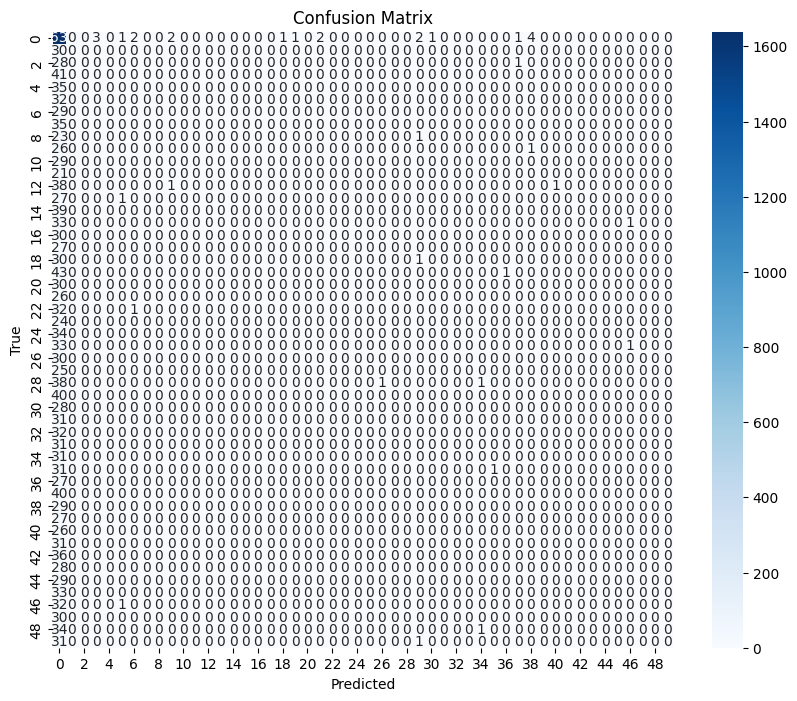

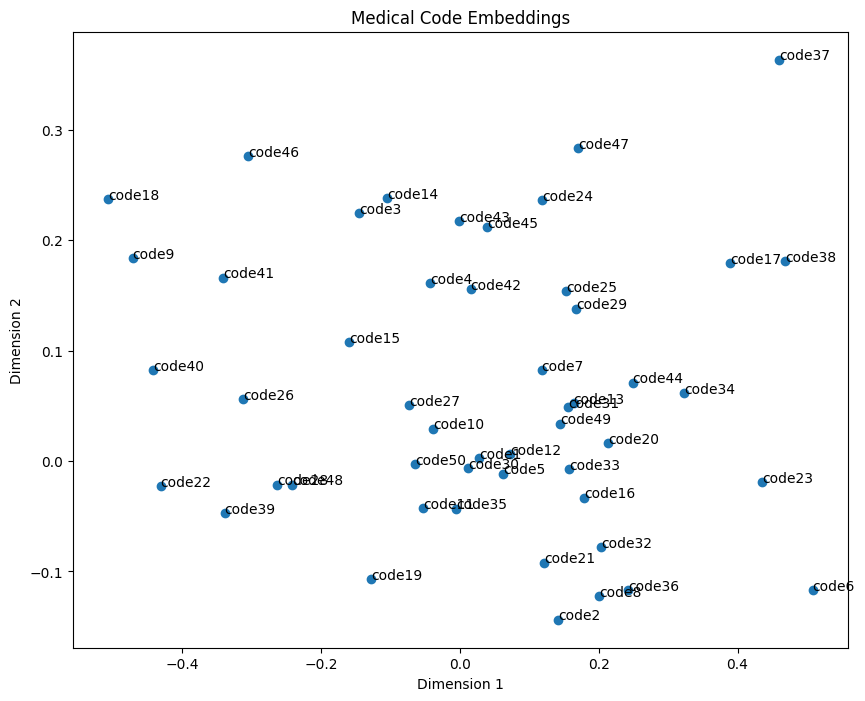

Interpretation of Results:
The model achieved a validation accuracy of 0.51.
The confusion matrix indicates the model's performance in predicting the correct medical codes.
The embeddings plot provides a visual representation of how different medical codes are related to each other.


In [6]:
# Final training on the full training set
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Predict on validation set
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=-1)

# Evaluate model
accuracy = accuracy_score(y_val.flatten(), y_pred.flatten())
conf_matrix = confusion_matrix(y_val.flatten(), y_pred.flatten())

print(f"Validation Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Visualizing embeddings
embedding_layer = model.get_layer('embedding')
embedding_weights = embedding_layer.get_weights()[0]

plt.figure(figsize=(10, 8))
plt.scatter(embedding_weights[:, 0], embedding_weights[:, 1])
for i, code in enumerate(le.classes_):
    plt.annotate(code, (embedding_weights[i, 0], embedding_weights[i, 1]))
plt.title("Medical Code Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

# Interpretation of results
print("Interpretation of Results:")
print(f"The model achieved a validation accuracy of {accuracy:.2f}.")
print("The confusion matrix indicates the model's performance in predicting the correct medical codes.")
print("The embeddings plot provides a visual representation of how different medical codes are related to each other.")